In [15]:
import os

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd


#### methods to load data

In [16]:
# Load data methods
def load_one_trial(trial_file):
    '''
    loads one trial and returns the csv file as a pandas dataframe
    '''
    return pd.read_csv(trial_file)

def load_all_trials(participant_dir):
    """Loads all trials of one participant and returns as a pandas dataframe"""
    all_dfs = []

    # Loop through all files in the folder
    for file_name in os.listdir(participant_dir):
        # Only process files that end with .csv
        if file_name.endswith(".csv"):
            # Construct the full path to the file
            file_path = os.path.join(participant_dir, file_name)

            # Load the individual trial and add it to our list
            trial_df = load_one_trial(file_path)
            all_dfs.append(trial_df)

    # Combine all individual DataFrames into a single continuous DataFrame
    if all_dfs:
        return pd.concat(all_dfs, ignore_index=True)
    else:
        return pd.DataFrame()  # Return empty DataFrame if no CSV files found

### methods to visualize trials

In [ ]:
# preprocess testdata to fix the swapping of cursor and gaze and wrong pixel factor

In [ ]:
def visualize_trial(trial_file):
    # 1. Load the trial data
    df = load_one_trial(trial_file)


    # 2. Extract unique trial number and target positions for the plot title/markers
    # (Assuming target coordinates and trial ID remain constant within a single trial file)
    trial_num = df["trial"].iloc[0]
    target_x = df["target_x"].iloc[0]
    target_y = df["target_y"].iloc[0]

    # 3. Create the plot
    plt.figure(figsize=(10, 8))

    # wrong screen width and pixel amount was used in params leading to conversion factor
    # and cursor_cm is stored in gaze (was switched in the update function by mistake)
    cursor_x_cm = df["gaze_x"]*42.72997032640949 *(59.7/33) 
    cursor_y_cm = df["gaze_y"]*42.72997032640949
    # Plot Cursor Trajectory in cm
    plt.plot(
        cursor_x_cm, # df["cursor_x_cm"] <- after fixing the data
        cursor_y_cm, # df["cursor_y_cm"] <- after fixing the data
        label="Cursor Path",
        color="royalblue",
        linewidth=2,
        marker="o",
        markersize=3,
        alpha=0.7,
    )


    # gaze is actually stored in the cursor variable (was switched in the update function by mistake)
    gaze_x = df["cursor_x_cm"]
    gaze_y = df["cursor_y_cm"]
    # Plot Gaze Trajectory
    plt.plot(
        gaze_x,      
        gaze_y,                 #
        label="Gaze Path",
        color="crimson",
        linewidth=1.5,
        linestyle="--",
        alpha=0.5,
    )

    # Highlight Start Point of the cursor
    plt.scatter(
        0,
        -360,
        color="green",
        s=100,
        zorder=5,
        label="Start Position",
    )

    # # Highlight End Point of the cursor
    # plt.scatter(
    #     df["cursor_x_cm"].iloc[-1],
    #     df["cursor_y_cm"].iloc[-1],
    #     color="red",
    #     s=100,
    #     zorder=5,
    #     label="End Position",
    # )

    # Plot Target Location
    plt.scatter(
        target_x,
        target_y,
        color="gold",
        edgecolors="black",
        s=200,
        marker="*",
        zorder=6,
        label="Target",
    )

    # 4. Customize plot appearance
    plt.title(f"Trajectory Visualization - Trial {trial_num}", fontsize=14)
    plt.xlabel("X Position (cm)", fontsize=12)
    plt.ylabel("Y Position (cm)", fontsize=12)
    plt.legend(loc="upper left")
    plt.grid(True, linestyle=":", alpha=0.6)
    plt.axis("equal")  # Keeps the aspect ratio 1:1 so distances aren't distorted

    # 5. Display the plot
    plt.show()



In [ ]:
# find out conversion factor
df = load_one_trial(trial_file)
factor = df["cursor_y_pix"][0]/df["gaze_y"][0]
factor # 

np.float64(42.72997032640949)

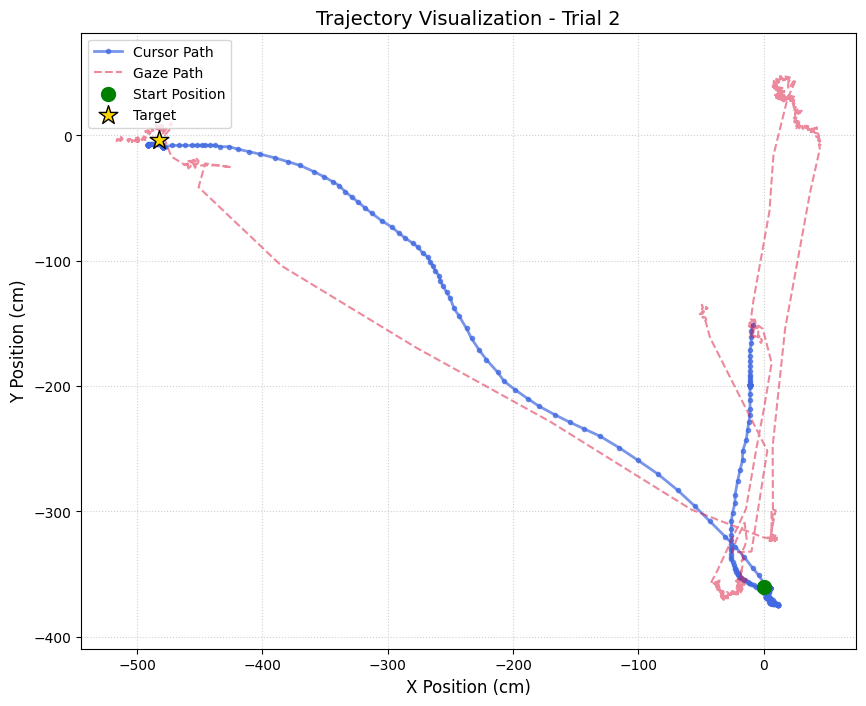

In [85]:
# define trial file
participant_id = "ge03"
participant_dir = "data/" + participant_id
block_n = 0
trial_n = 2
trial_file = participant_dir + "/participant_" + participant_id + "_block_" + str(block_n) +"_trial_" + str(trial_n) + "_trajectory.csv"

#visualise trial
visualize_trial(trial_file)